# Day 5 control: trimmed-mean consensus — robust aggregation

Reads `outputs/day5_trimmed.json` — the IID `β × trim_k` sweep on
RoBERTa+SST-2 produced by `scripts/run_trimmed.py`
(`notebooks/colab_run_trimmed.ipynb` in Colab). The `trim_k=0` column
(no trimming) is the existing IID reputation run
`outputs/day5_reputation_iid.json`, loss mode.

**Idea.** Day 4: reputation softly *down-weights* bad agents and
cascades. Trimmed-mean is the stable form of "steer away from the bad
agents": the worst `trim_k` agents by probe loss are *hard-dropped*
from the centroid each consensus round. `W` stays non-negative and
row-stochastic — unlike true repulsion (`W_ij < 0`), which breaks the
Day-3 spectral contraction and diverges. Byzantine-robust aggregator
family — trimmed mean / Krum, Yin et al. 2018. `trim_k` composes with
β: `β=0` → plain trimmed mean (uniform over survivors), `β>0` →
reputation-weighting among survivors.

Grid: `β ∈ {0, 0.1, 0.5, 1, 10} × trim_k ∈ {2, 4}`, N=8 agents, IID
split. `trim_k=4` drops *half* the swarm — an aggressive limit, the
stress end of the axis, not a proposed working point.

The question: does hard-dropping the worst agents buy accuracy over
plain FedAvg-MeZO (`β=0`, `trim_k=0`)?

## Load `day5_trimmed.json` + the `trim_k=0` baseline

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
d = json.loads((ROOT / 'outputs' / 'day5_trimmed.json').read_text(encoding='utf-8'))
print('config:', d['config'])

runs  = d['runs']
betas = sorted({h['beta']   for h in runs.values()})
trims = sorted({h['trim_k'] for h in runs.values()})
N = d['config']['n_agents']
print(f"β = {betas}   trim_k = {trims}   ({len(runs)} runs)")

# trim_k=0 column = the existing IID reputation run (loss mode).
rep = json.loads((ROOT / 'outputs' / 'day5_reputation_iid.json').read_text(encoding='utf-8'))
base_runs = {h['beta']: h for h in rep['runs'].values()
             if h.get('mode', 'loss') == 'loss'}
fedavg      = base_runs[0.0]['eval_acc'][-1]
fedavg_loss = base_runs[0.0]['eval_loss'][-1]
print(f"FedAvg baseline (β=0, trim_k=0): acc {fedavg:.4f}, CE loss {fedavg_loss:.4f}")

# Colour encodes β; one panel/marker per trim_k.
cmap = plt.get_cmap('viridis')
bcolor = {b: cmap(i / max(len(betas) - 1, 1)) for i, b in enumerate(betas)}
plt.rcParams['figure.dpi'] = 110

config: {'model': 'roberta-base', 'train_subset': 1000, 'probe_size': 32, 'total_steps': 5000, 'mezo_lr': 1e-06, 'mezo_eps': 0.001, 'eval_every': 500, 'n_agents': 8, 'local_steps': 100, 'sharding': 'iid', 'gamma_r': 1.0, 'mode': 'loss+trim', 'agent_class_balance': [[62, 63], [56, 69], [48, 77], [55, 70], [55, 70], [57, 68], [49, 76], [58, 67]]}
β = [0.0, 0.1, 0.5, 1.0, 10.0]   trim_k = [2, 4]   (10 runs)
FedAvg baseline (β=0, trim_k=0): acc 0.8876, CE loss 0.3100


## Plot 1 — val accuracy & CE loss vs step, one panel per `trim_k`

Top row = accuracy, bottom row = CE loss. Each coloured line is a β.
The faint dashed line in each panel is the matching-β `trim_k=0` run
(no trimming) — so each solid curve reads directly against its no-trim
counterpart. The dotted grey horizontal is plain FedAvg-MeZO.

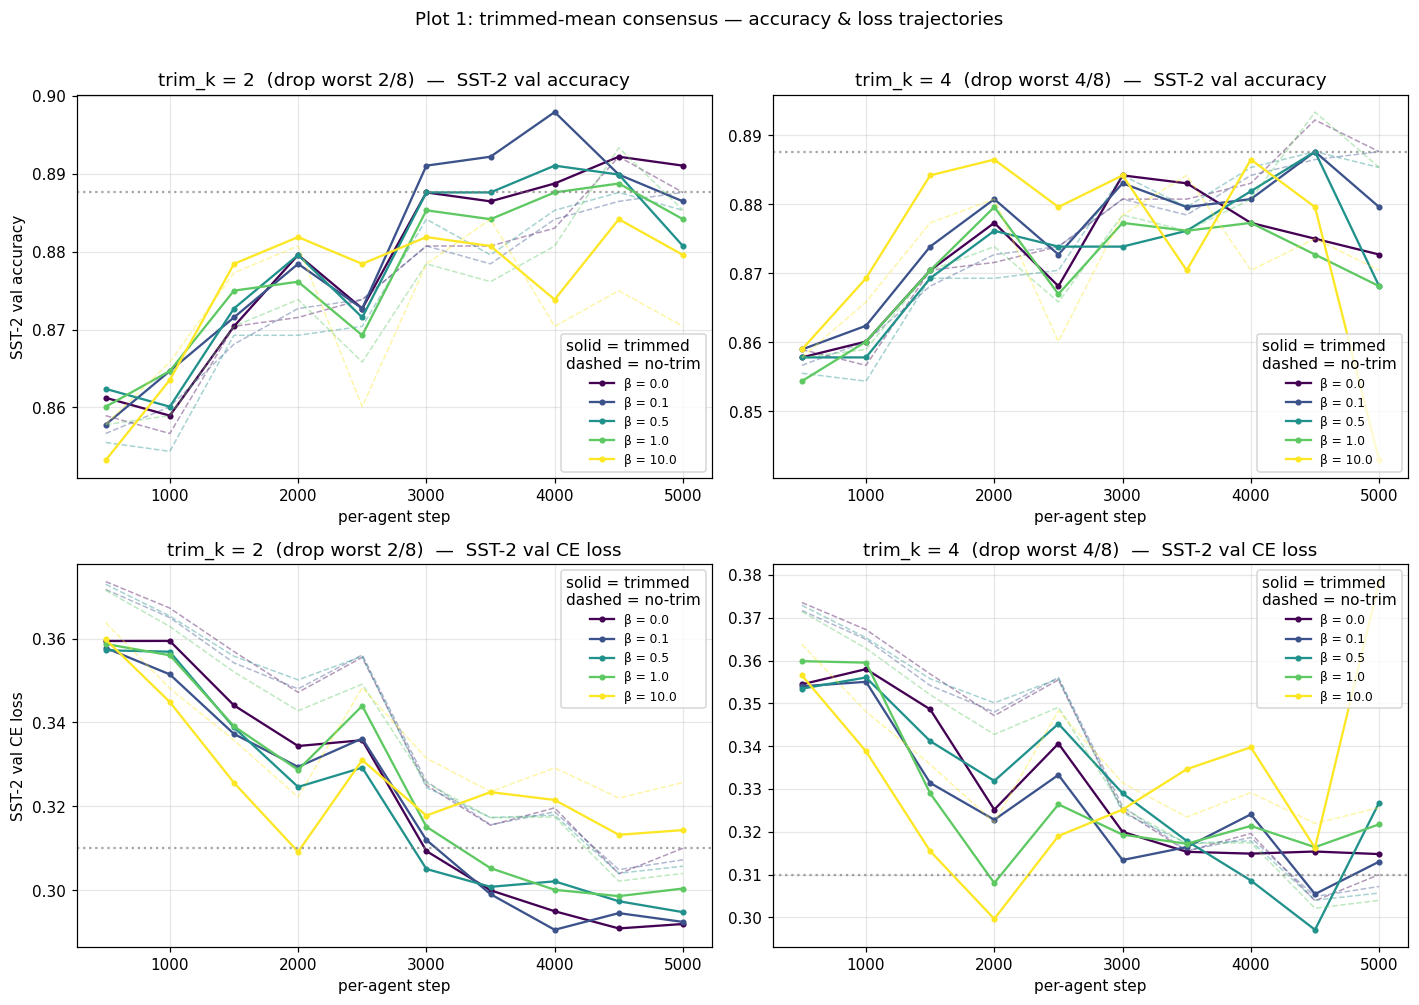

In [2]:
nt = len(trims)
fig, axes = plt.subplots(2, nt, figsize=(6.5 * nt, 9), squeeze=False)
for row, (key, ylabel, hline) in enumerate([
        ('eval_acc',  'SST-2 val accuracy', fedavg),
        ('eval_loss', 'SST-2 val CE loss',  fedavg_loss)]):
    for col, k in enumerate(trims):
        ax = axes[row][col]
        for b in betas:
            h = runs.get(f'beta{b}_trim{k}')
            if h:
                ax.plot(h['eval_step'], h[key], marker='o', markersize=3,
                        color=bcolor[b], label=f'β = {b}')
            bh = base_runs.get(b)
            if bh:
                ax.plot(bh['eval_step'], bh[key], ls='--', lw=1, alpha=0.4,
                        color=bcolor[b])
        ax.axhline(hline, color='gray', ls=':', alpha=0.7)
        ax.set_xlabel('per-agent step'); ax.grid(True, alpha=0.3)
        ax.set_title(f'trim_k = {k}  (drop worst {k}/{N})  —  {ylabel}')
        ax.legend(fontsize=8, title='solid = trimmed\ndashed = no-trim')
        if col == 0:
            ax.set_ylabel(ylabel)
plt.suptitle('Plot 1: trimmed-mean consensus — accuracy & loss trajectories',
             y=1.01)
plt.tight_layout()

## Plot 2 — final val accuracy vs β (the headline)

Three lines: `trim_k ∈ {0, 2, 4}`. The dashed grey line is plain
FedAvg-MeZO. The claim to read off: trimming the worst agents does not
open a working window above the baseline — at best `trim_k=2` is a
wash, and `trim_k=4` (half the swarm dropped) and large β both lose
accuracy. β does not rescue trimming, and trimming does not rescue β.

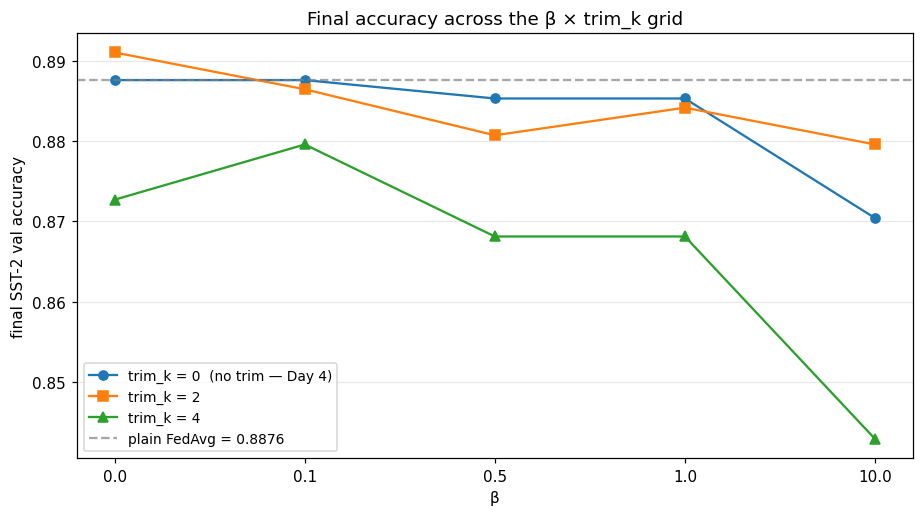

In [3]:
series = {0: {b: base_runs[b]['eval_acc'][-1] for b in betas if b in base_runs}}
for k in trims:
    series[k] = {b: runs[f'beta{b}_trim{k}']['eval_acc'][-1]
                 for b in betas if f'beta{b}_trim{k}' in runs}

x = np.arange(len(betas))
markers = {0: 'o', 2: 's', 4: '^'}
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for k, sb in series.items():
    ax.plot(x, [sb.get(b, np.nan) for b in betas], marker=markers.get(k, 'o'),
            label=f'trim_k = {k}' + ('  (no trim — Day 4)' if k == 0 else ''))
ax.axhline(fedavg, color='gray', ls='--', alpha=0.7,
           label=f'plain FedAvg = {fedavg:.4f}')
ax.set_xticks(x); ax.set_xticklabels([str(b) for b in betas])
ax.set_xlabel('β'); ax.set_ylabel('final SST-2 val accuracy')
ax.set_title('Final accuracy across the β × trim_k grid')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

## Plot 3 — reputation concentration over rounds (cascade detector)

`max_i r_i / Σ_j r_j` per consensus round; uniform = `1/N`. Reputation
state still tracks all N agents (trimming masks only the *applied*
mixing row), so this shows whether stacking β on top of trimming still
triggers the Day-4 cascade. Expect `β=10` to concentrate hard.

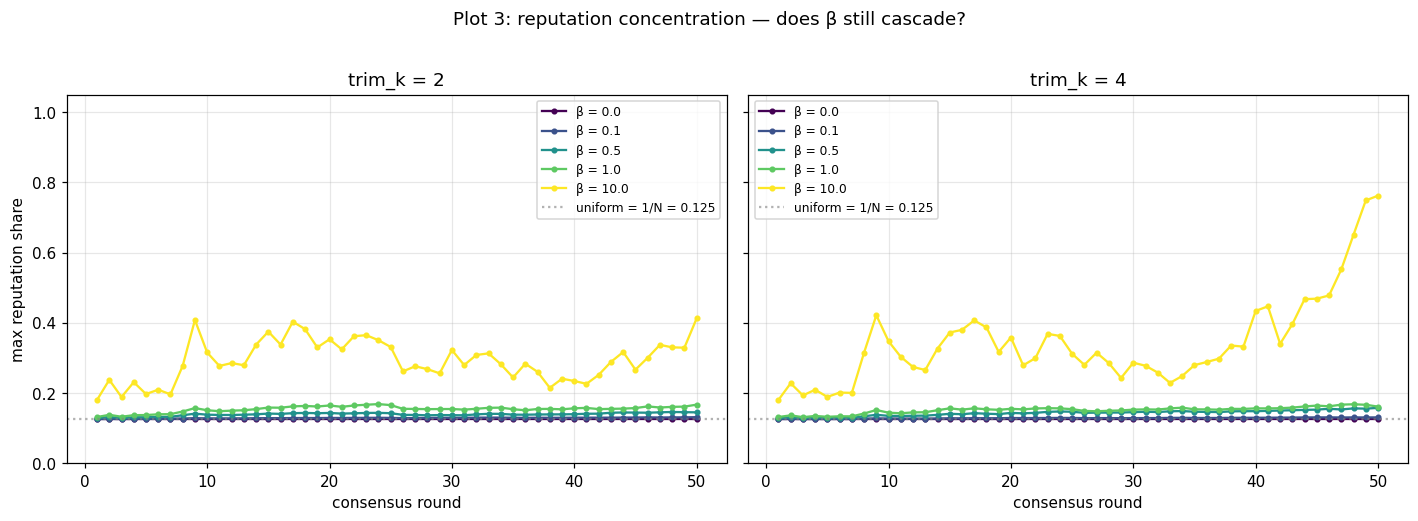

In [4]:
def _max_share(h):
    reps = np.asarray(h.get('reputations') or [])
    if reps.size == 0:
        return None
    return (reps / reps.sum(axis=1, keepdims=True)).max(axis=1)

fig, axes = plt.subplots(1, len(trims), figsize=(6.5 * len(trims), 4.6),
                         sharey=True, squeeze=False)
for ax, k in zip(axes[0], trims):
    for b in betas:
        h = runs.get(f'beta{b}_trim{k}')
        ms = _max_share(h) if h else None
        if ms is not None:
            ax.plot(np.arange(1, len(ms) + 1), ms, marker='o', markersize=3,
                    color=bcolor[b], label=f'β = {b}')
    ax.axhline(1 / N, color='gray', ls=':', alpha=0.6,
               label=f'uniform = 1/N = {1 / N:.3f}')
    ax.set_title(f'trim_k = {k}')
    ax.set_xlabel('consensus round'); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
axes[0][0].set_ylabel('max reputation share')
plt.suptitle('Plot 3: reputation concentration — does β still cascade?', y=1.02)
plt.tight_layout()

## Summary table

`Δ vs FedAvg` is final accuracy minus the plain FedAvg-MeZO baseline —
positive only where robust aggregation actually helped. The `trim_k=0`
rows are the Day-4 reputation runs, shown for reference.

In [5]:
rows = []
for k in [0] + trims:
    for b in betas:
        if k == 0:
            h = base_runs.get(b)
            name = f'beta{b}_trim0'
        else:
            h = runs.get(f'beta{b}_trim{k}')
            name = f'beta{b}_trim{k}'
        if h is None:
            continue
        ms = _max_share(h)
        rows.append({
            'run':            name,
            'β':              b,
            'trim_k':         k,
            'final val_acc':  h['eval_acc'][-1],
            'Δ vs FedAvg':    h['eval_acc'][-1] - fedavg,
            'final val_loss': h['eval_loss'][-1],
            'max rep share':  float(ms[-1]) if ms is not None else float('nan'),
        })
pd.DataFrame(rows).sort_values(['trim_k', 'β']).round(4).reset_index(drop=True)

,run,β,trim_k,final val_acc,Δ vs FedAvg,final val_loss,max rep share
0,beta0.0_trim0,0.0,0,0.8876,0.0000,0.3100,0.1250
1,beta0.1_trim0,0.1,0,0.8876,0.0000,0.3072,0.1313
2,beta0.5_trim0,0.5,0,0.8853,-0.0023,0.3057,0.1506
3,beta1.0_trim0,1.0,0,0.8853,-0.0023,0.3040,0.1895
4,beta10.0_trim0,10.0,0,0.8704,-0.0172,0.3256,0.3668
5,beta0.0_trim2,0.0,2,0.8911,0.0034,0.2919,0.1250
6,beta0.1_trim2,0.1,2,0.8865,-0.0011,0.2924,0.1311
7,beta0.5_trim2,0.5,2,0.8807,-0.0069,0.2948,0.1449
8,beta1.0_trim2,1.0,2,0.8842,-0.0034,0.3004,0.1668
9,beta10.0_trim2,10.0,2,0.8796,-0.0080,0.3143,0.4124
